# Mutli-fidelity optimization - VF-PI


In [1]:
import numpy as np
from matplotlib import pyplot as plt

from smt_optim.benchmarks.registry import get_problem

from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtMFCK

from smt_optim.acquisition_strategies import VFPI

## Unconstrained 1D optimization

In [2]:
# high-fidelity function
def sasena2002_hf(x):
    return -np.sin(x) - np.exp(x / 100) + 10

# low-fidelity function
def sasena2002_lf(x):
    return sasena2002_hf(x) + 0.3 + 0.03 * (x - 3) ** 2

bounds = np.array([[0, 10]])

x_valid = np.linspace(bounds[:, 0], bounds[:, 1], 101)
y_hf = sasena2002_hf(x_valid)
y_lf = sasena2002_lf(x_valid)

In [3]:
obj_config = ObjectiveConfig(
    objective=[sasena2002_lf, sasena2002_hf],   # multi-fidelity functions must be given in sequential order
    type="minimize",
    surrogate=SmtMFCK,
)


prob_definition = Problem(
    obj_configs=[obj_config],
    design_space=bounds,
    costs=[0.2, 1],                 # Set the cost of sampling each level
)


xt_init = [np.array([[0.5], [2.5], [9.5]]) for _ in range(2)]

opt_config = DriverConfig(
    max_iter = 10,
    max_budget = 10,                # stopping criterion
    xt_init = xt_init,
    verbose = True,
    scaling = True,
    seed=42,
)

optimizer = Driver(prob_definition, opt_config, VFPI)

state = optimizer.optimize()

          iter         budget           fmin       fidelity        gp_time       acq_time
             1          3.800    8.37621e+00              1          0.690          0.410
             2          4.000    8.37621e+00              1          0.736          0.324
             3          4.200    8.37621e+00              1          0.656          0.237
             4          4.400    8.37621e+00              1          0.692          0.247
             5          4.600    8.37621e+00              1          0.683          0.231
             6          4.800    8.37621e+00              1          0.688          0.223
             7          5.000    8.37621e+00              1          0.676          0.222
             8          5.200    8.37621e+00              1          0.709          0.225
             9          6.200    8.04212e+00              2          0.724          0.236
            10          7.200    7.92156e+00              2          0.684          0.273


In [4]:
data = state.dataset.export_as_dict()
fidelity_masks = [(data["fidelity"] == lvl).ravel() for lvl in range(state.problem.num_fidelity)]
xt = [data["x"][fidelity_masks[lvl], 0] for lvl in range(state.problem.num_fidelity)]
yt = [data["obj"][fidelity_masks[lvl], 0] for lvl in range(state.problem.num_fidelity)]


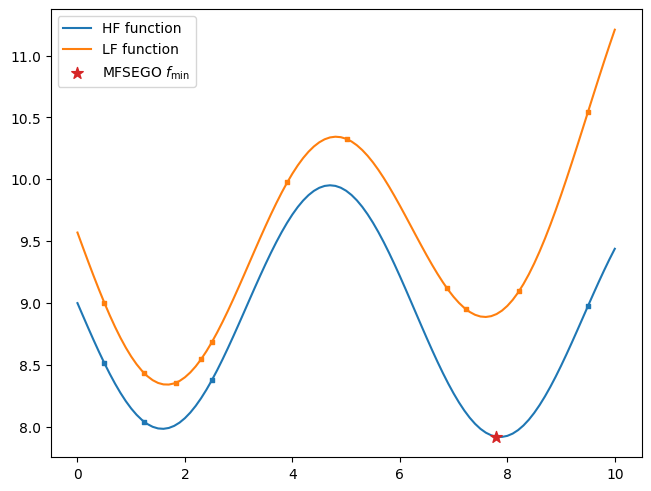

In [5]:
sample = state.get_best_sample()

fig, ax = plt.subplots(layout="constrained")
ax.plot(x_valid, y_hf, label="HF function")
ax.plot(x_valid, y_lf, label="LF function")

for lvl in reversed(range(2)):
    ax.scatter(xt[lvl], yt[lvl], 5, marker="s")

ax.scatter(sample.x, sample.obj, 75, marker="*", color="C3", zorder=20, label=r"MFSEGO $f_{\min}$")

plt.legend()
plt.show()

## Constrained 2D optimization

### Importing a test function

In [6]:
problem = get_problem("Rosenbrock")

### VF-PI Configuration

In [7]:
obj_config = ObjectiveConfig(
    problem.objective,
    type="minimize",
    surrogate=SmtMFCK,

)

# configure the constraint
cstr_config = ConstraintConfig(
    problem.constraints[0],
    type="less",                    # set the constraint type (less, greater or equal)
    value=0.0,                      # g(x) <= 0
    surrogate=SmtMFCK,               # set which GP to model this constraint
)


prob_definition = Problem(
    obj_configs=[obj_config],
    design_space=problem.bounds,
    costs=[0.2, 1],                 # Set the cost of sampling each level
    cstr_configs=[cstr_config],
)


opt_config = DriverConfig(
    max_iter = 30,
    max_budget = 20,                # stopping criterion
    nt_init = 5,
    verbose = True,
    scaling = True,
    seed=42,
)

optimizer = Driver(prob_definition, opt_config, VFPI, strategy_kwargs={"density_penalty": True})

state = optimizer.optimize()

          iter         budget           fmin       fidelity        gp_time       acq_time
             1          7.200    2.85223e+02              1          2.500          2.363
             2          7.400    2.85223e+02              1          2.570          1.163
             3          7.600    2.85223e+02              1          2.743          1.284
             4          7.800    2.85223e+02              1          2.916          1.381
             5          8.800    3.20695e+00              2          3.190          1.523
             6          9.000    3.20695e+00              1          2.728          1.192
             7          9.200    3.20695e+00              1          3.641          1.152
             8          9.400    3.20695e+00              1          2.593          1.074
             9          9.600    3.20695e+00              1          2.439          1.177
            10         10.600    3.20695e+00              2          2.685          1.264
          

best sample = 
======= sample data =======
x =             [-0.02562273  0.10992281]
obj =           [2.24581415]
cstr =          [-0.44438207]
eval_time =     [3.24099892e-06 2.11699808e-06]
------- meta data -------
iter =     12
budget =     11.799999999999997
fidelity =     1



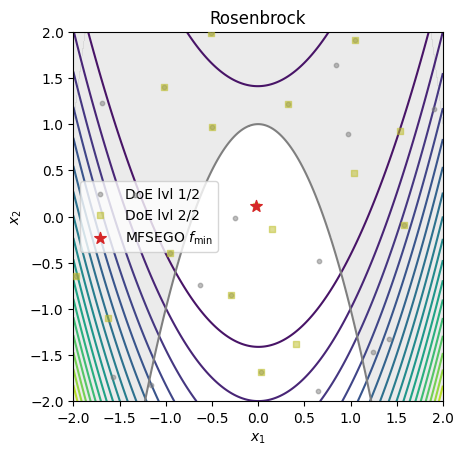

In [8]:
data_x = []
for lvl in range(state.problem.num_fidelity):
    samples = state.dataset.get_by_fidelity(lvl)
    data_x.append(np.empty((len(samples), state.problem.num_dim)))
    for idx, s in enumerate(samples):
        data_x[lvl][idx, :] = s.x

sample = state.get_best_sample(ctol=1e-4)
print(f"best sample = \n{sample}")

X = np.linspace(problem.bounds[0, 0], problem.bounds[0, 1], 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = np.empty(data.shape[0])

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :])
    c[i] = problem.constraints[0][-1](data[i, :])

Z = z.reshape(XX.shape)
C = c.reshape(XX.shape)

fig, ax = plt.subplots()

ax.set_title(problem.name)

ax.contour(XX, YY, Z, levels=20)

ax.contourf(XX, YY, np.where(C <= 0, np.nan, C), levels=0, colors="C7", alpha=0.15)
ax.contour(XX, YY, C, levels=[0], colors="C7")

ax.scatter(data_x[0][:, 0], data_x[0][:, 1], 10, color="C7", marker="o", alpha=0.5, label="DoE lvl 1/2", zorder=10)
ax.scatter(data_x[1][:, 0], data_x[1][:, 1], 20, color="C8", marker="s", alpha=0.5, label="DoE lvl 2/2", zorder=20)

ax.scatter(sample.x[0], sample.x[1], 75, c="C3", marker="*", label=r"MFSEGO $f_{\min}$", zorder=30)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")

ax.legend()
ax.set_aspect("equal")
plt.show()